---
title: Moments and distributions
---

In [1]:
from phasic import Graph, with_ipv
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
sns.set_palette('tab10')
from vscodenb import set_vscode_theme
set_vscode_theme()
np.random.seed(42)

Define a graph:

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

Build the graph:

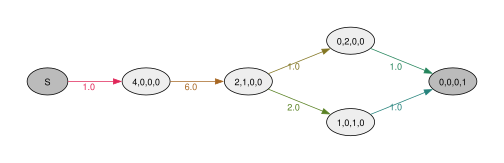

In [3]:
graph = Graph(coalescent)
graph.plot()

## Mean, variance, and higher moments

This phase-type distribution models the time until all lineages have coalesced. For convenience, we can get its expectation and variance like this:

In [4]:
graph.expectation()

1.4999999999999996

In [5]:
graph.variance()

1.1388888888888893

You can get any number of moments like this (here three):

In [6]:
graph.moments(3)

[1.4999999999999996, 3.388888888888888, 10.583333333333332]

In [7]:
#| echo: false
if 'pytest' in sys.modules: assert pytest.approx(graph.expectation()) == 1.5

In [8]:
#| echo: false
if 'pytest' in sys.modules: assert pytest.approx(graph.variance()) == 1.1388888

## Expected waiting time at states

In addition to the waiting time from the starting state, we can compute exact expected waiting times from each state:        

In [9]:
graph.expected_waiting_time()

[1.4999999999999996, 1.4999999999999996, 1.333333333333333, 1.0, 1.0, 0.0]

Or with the state vectors:

In [10]:
pd.DataFrame(graph.states()).assign(expectation=graph.expected_waiting_time())

,0,1,2,3,expectation
0,0,0,0,0,1.500000
1,4,0,0,0,1.500000
2,2,1,0,0,1.333333
3,0,2,0,0,1.000000
4,1,0,1,0,1.000000
5,0,0,0,1,0.000000


These expectations are used to compute higher moments. The MGF has the beautiful property that all moments are expectations with rewards derived from lower moment expectations at each state. Here is the first and second one again:

In [11]:
graph.expectation(), 2 * graph.expectation(graph.expected_waiting_time())

(1.4999999999999996, 3.388888888888888)

## Expected total time spent in states

Compute the exact expected total time spent in each state:

In [12]:
graph.expected_sojourn_time()

[0.0,
 0.16666666666666663,
 0.33333333333333326,
 0.3333333333333333,
 0.6666666666666666,
 0.0]

## CDF / PDF

We can get the CDF and PDF. The distribution methods reuse cached computations and recompute only if the graph changes. Compare the running times for the first and second call to the function:

In [13]:
time = np.arange(0, 4, 0.001)

In [14]:
%%time
cdf = graph.cdf(time)

CPU times: user 224 μs, sys: 33 μs, total: 257 μs
Wall time: 262 μs


In [15]:
%%time
cdf = graph.cdf(time)

CPU times: user 44 μs, sys: 3 μs, total: 47 μs
Wall time: 48.2 μs


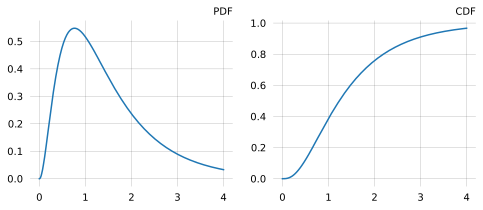

In [16]:
#| label: fig-pdf-cdf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.plot(time, graph.pdf(time))
ax1.set_title("PDF")
ax2.plot(time, graph.cdf(time))
ax2.set_title("CDF") ;

## Rewards

**Shape.** Rewards must be a 1-D array of length `n_vertices` (one reward per vertex) or a 2-D array of shape `(n_features, n_vertices)` for multivariate phase-type distributions where each feature has its own reward vector.

We can add rewards which are based on the number of doubletons:

In [17]:
graph = Graph(coalescent)
reward_matrix = graph.states().T
doubletons = reward_matrix[1]
doubletons

array([0, 0, 1, 2, 0, 0], dtype=int32)

Adding these rewards, the phase-type distribution now represent the total doubleton branch length (total length of branches with two descendants). The expectation and variance are now:

In [18]:
graph.expectation(doubletons), graph.variance(doubletons)

(0.9999999999999999, 2.333333333333333)

Using rewards to the moment functions etc. is much faster than changing the graph. Here is the SFS (Site Frequency Spectrum) computed in this way. The 4'ton is included to illustrate that it is represented but has expectation zero since this it the absorbing TMRCA.

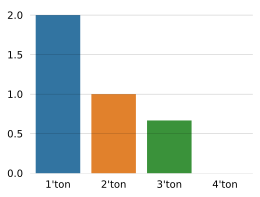

In [19]:
#| label: fig-sfs
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[0])]
sfs = [graph.expectation(r) for r in reward_matrix]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels, y=sfs, hue=labels) ;

### Reward transforms

And here by doing each reward_transform:

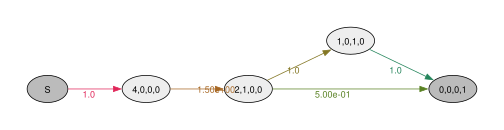

In [20]:
#| label: fig-singleton-rev-trans
singleton_graph = graph.reward_transform(reward_matrix[0])
singleton_graph.plot()

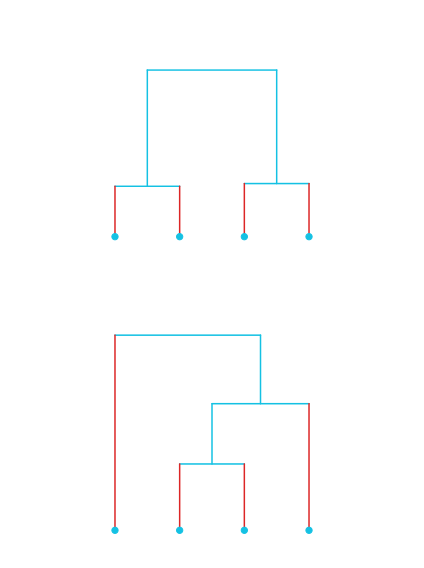

In [21]:
#| echo: false 
#| label: fig-singleton-branches
#| column: margin
#| fig-cap: "Singleton branch length"
from phasic.utils import tree_illustration
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))
tree_illustration('TTTT', ton=1, ton_label=False, balanced=False, seed=1, ax=ax1);
tree_illustration('TTTT', ton=1, ton_label=False, balanced=False, seed=2, ax=ax2);
plt.tight_layout()

In [22]:
reward_matrix[1]

array([0, 0, 1, 2, 0, 0], dtype=int32)

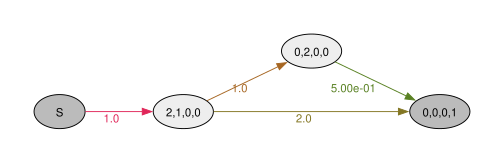

In [23]:
#| label: fig-doubleton-rev-trans
doubleton_graph = graph.reward_transform(reward_matrix[1])
doubleton_graph.plot()

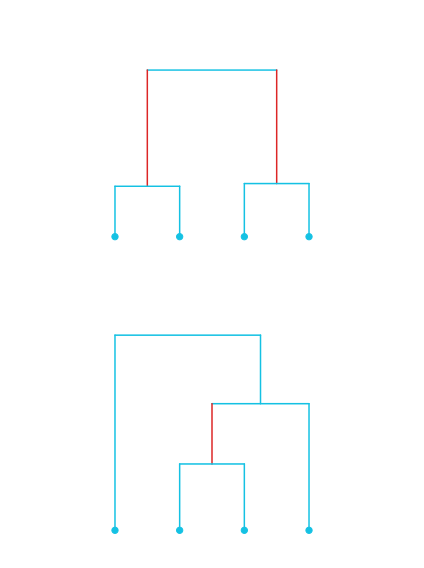

In [24]:
#| echo: false 
#| label: fig-doubleton-branches
#| column: margin
#| fig-cap: "Double branch length"
from phasic.utils import tree_illustration
# tree_illustration('TTTT', ton=2, ton_label=False, seed=4) ;
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))
tree_illustration('TTTT', ton=2, ton_label=False, balanced=False, seed=1, ax=ax1);
tree_illustration('TTTT', ton=2, ton_label=False, balanced=False, seed=2, ax=ax2);
plt.tight_layout()

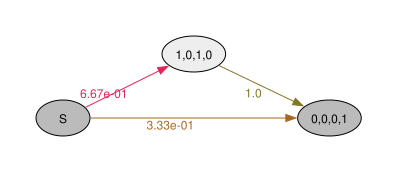

In [25]:
#| label: fig-tripleton-rev-trans
tripleton_graph = graph.reward_transform(reward_matrix[2])
tripleton_graph.plot()

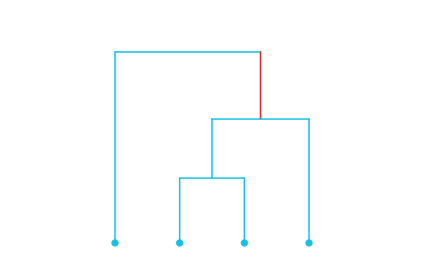

In [26]:
#| echo: false 
#| label: fig-tripleton-branches
#| column: margin
#| fig-cap: "Tripleton branch length"
from phasic.utils import tree_illustration
tree_illustration('TTTT', ton=3, ton_label=False, balanced=False, seed=2) ;

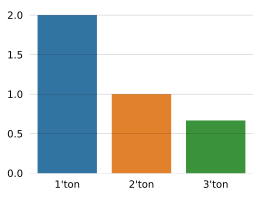

In [27]:
sfs = [
    singleton_graph.expectation(),
    doubleton_graph.expectation(),
    tripleton_graph.expectation(),
]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels[:len(sfs)], y=sfs, hue=labels[:len(sfs)]) ;

Computing the (unrewarded) expectation on the reward-transforming graph produces the same result as passing the rewards to `expectation`, but is much slower:

In [28]:
graph = Graph(coalescent)
singleton_rewards = graph.states().T[0]

In [29]:
%%timeit
graph.expectation(singleton_rewards)

5.4 μs ± 956 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [30]:
%%timeit
graph.reward_transform(singleton_rewards).expectation()

35.9 μs ± 5.99 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


The real use of reward transformation is that it provides the full distribution of accumulated rewards. For example if we want the marginal distributions:

In [31]:
graph.states().T[:-1]

array([[0, 4, 2, 0, 1, 0],
       [0, 0, 1, 2, 0, 0],
       [0, 0, 0, 0, 1, 0]], dtype=int32)

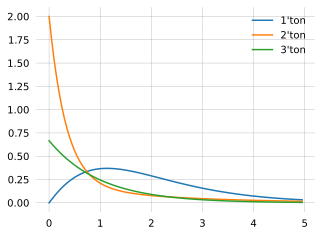

In [32]:
#| label: fig-sfs-marginal-pdfs
#| legend: "Marginal PDFs. Notice the how 3'ton branch lengths do not zum to one because it has a point mass at zero."
graph = Graph(coalescent)
times = np.arange(0, 5, 0.05)
reward_matrix = graph.states().T
reward_matrix = reward_matrix[:-1]
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[1])]

for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    plt.plot(times, revt_graph.pdf(times), label=labels[i])
plt.legend() ;

Marginal distributions can have a point mass at zero. In out coalescent example, there is a non-zero probability there is no 3'ton branch at all. The marginal PDF can only represent the continuous part, but the point mass is represented as the deficit when the PDF is integrated over rewards (I.e., the probability distribution does not sum to one). In the CDF, the point mass is clearly represented as the cumulative probability at zero reward: The 3'ton CDF does not begin at zero probability like the 1'ton and 2'ton.

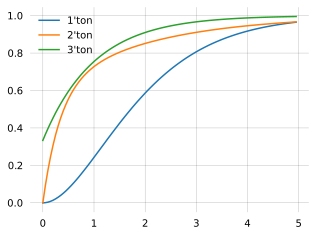

In [33]:
#| label: fig-sfs-marginal-cdfs
#| legend: "Marginal CDFs. Notice the point mass at zero for 3'ton branch length."
for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    plt.plot(times, revt_graph.cdf(times), label=labels[i])
plt.legend() ;

In [34]:
times = np.arange(0, 20, 0.00001)
for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    print(np.sum(revt_graph.pdf(times) * 0.00001))

0.9999999901057668
1.0019446704033461
0.6673209340391812


## State probability over time

### State probability

Alias for `stop_probability`. Computes the state probability, the probabilities of occupying each state at time t. 

In [35]:
graph = Graph(coalescent)
graph.state_probability(0.2)

[0.0,
 0.29978049956512576,
 0.4964527753776389,
 0.06299978987254216,
 0.12599957974508433,
 0.0]

We can use that to compute the expected number of lineages across time:

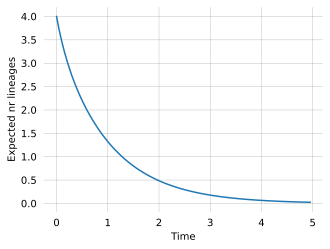

In [36]:
#| label: fig-tot-lineages-across-time
times = np.arange(0, 5, 0.05)
expected_lineages_left = [
    np.sum(graph.state_probability(i) 
           * np.sum(graph.states(), axis=1)) 
    for i in times
    ]

fig, ax = plt.subplots(1, 1)
ax.plot(times, expected_lineages_left)
ax.set_xlabel('Time')
ax.set_ylabel("Expected nr lineages") ;

We can also get the accumulated visiting time of a particular state. E.g. the total doubleton branchlength before time t=1.5:

The same way we can also compute the expected number of *each kind* of lineage across time:

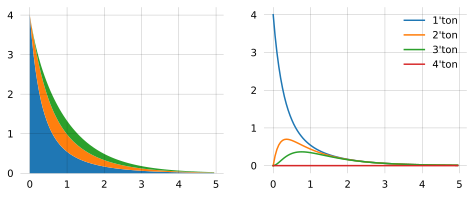

In [37]:
#| label: fig-ton-lineages-across-time
times = np.arange(0, 5, 0.05)
state_probs = np.array([graph.state_probability(i) * graph.states().T for i in times])
labels = [f"{i+1}'ton" for i in range(state_probs.shape[1])]
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].stackplot(times, np.sum(state_probs, axis=2).T)
axes[1].plot(times, np.sum(state_probs, axis=2), label=labels)
# plt.subplot(121).stackplot(times, np.sum(state_probs, axis=2).T)
# plt.subplot(122).plot(times, np.sum(state_probs, axis=2), label=labels)
plt.legend() ;

### Accumulated time spent in states by time

Total time spent in each state up to time t:

In [38]:
graph.accumulated_occupancy(0.3)

[0.0,
 0.13955067135532132,
 0.11830247033054878,
 0.013473490250327203,
 0.026946980500654406,
 0.0]

You can plot the accumulated occupancies along to see how they converge to the expected sojourn times (dashed lines):

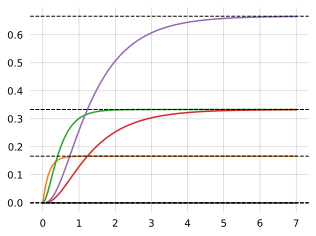

In [39]:
#| label: fig-accumulated-occupancies

times = np.linspace(0, 7, 100)
plt.plot(times, [graph.accumulated_occupancy(t) for t in times])
[plt.gca().axhline(t, ls='--', c='k', lw=1) for t in graph.expected_sojourn_time()] ;

# Random sampling

The library includes functions to do random sampling. These are useful to also validate the computations

In [40]:
graph = Graph(coalescent)
graph.sample(5)

array([2.76603799, 0.39756829, 0.9225643 , 0.46875124, 0.23534204])

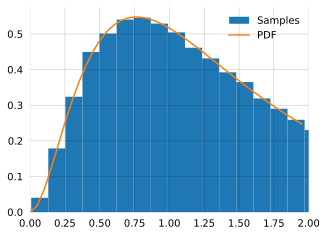

In [41]:
#| label: fig-tmrca-sampling-dist
#| fig-cap: "Sampling distribution."


fig, ax = plt.subplots()
samples = graph.sample(100000)

ax.hist(samples, bins=100, density=True, label='Samples')
x = np.arange(0, 2, 0.05)

ax.plot(x, [graph.pdf(t) for t in x], label='PDF')

ax.set_xlim(0, 2)
ax.legend();

You can produce the moments from sampling if needed. Here is the empirical first moment computed from samples compared ot the exact first moment:

In [42]:
np.sum(np.array(graph.sample(10000))).item()/10000, graph.moments(1)[0]

(1.5062527192977253, 1.4999999999999996)

Here is the empirical second moment computed from samples compared ot the exact second moment:

In [43]:
np.sum(np.array(graph.sample(10000))**2).item()/10000, graph.moments(2)[1]

(3.3509435909804335, 3.388888888888888)